# Makemore Part 5: WaveNet 스타일 구현

> 📺 Andrej Karpathy - "Building a WaveNet"
> 🔗 https://www.youtube.com/watch?v=t3YJ5hKiMQ0

**핵심**: 인접 문자부터 계층적으로 융합하는 깊은 네트워크

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 데이터 준비

In [2]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
block_size = 8  # 더 긴 컨텍스트

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
print(f'Train: {Xtr.shape}, Val: {Xdev.shape}')

Train: torch.Size([182625, 8]), Val: torch.Size([22655, 8])


---
## 📺 15:00 - 35:00 | 모듈 정의

PyTorch 스타일의 모듈 클래스 직접 구현

In [3]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean.mean(list(range(x.ndim - 1)))
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar.mean(list(range(x.ndim - 1)))
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    """인접한 n개 토큰을 하나로 합침"""
    def __init__(self, n):
        self.n = n
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

---
## 📺 35:00 - 55:00 | WaveNet 스타일 모델 구축

8개 문자 → (쌍 융합)×3 → 예측

In [4]:
n_embd = 24
n_hidden = 128

torch.manual_seed(42)
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1  # 마지막 레이어 축소

parameters = model.parameters()
for p in parameters:
    p.requires_grad = True

print(f'총 파라미터 수: {sum(p.nelement() for p in parameters)}')

총 파라미터 수: 76579


In [5]:
# 각 레이어의 출력 shape 확인
x = Xtr[:4]
for layer in model.layers:
    x = layer(x)
    print(f'{layer.__class__.__name__:22s} → {str(list(x.shape)):18s}')

Embedding              → [4, 8, 24]        
FlattenConsecutive     → [4, 4, 48]        
Linear                 → [4, 4, 128]       
BatchNorm1d            → [4, 4, 128]       
Tanh                   → [4, 4, 128]       
FlattenConsecutive     → [4, 2, 256]       
Linear                 → [4, 2, 128]       
BatchNorm1d            → [4, 2, 128]       
Tanh                   → [4, 2, 128]       
FlattenConsecutive     → [4, 256]          
Linear                 → [4, 128]          
BatchNorm1d            → [4, 128]          
Tanh                   → [4, 128]          
Linear                 → [4, 27]           


---
## 📺 55:00 - 01:10:00 | 학습

In [6]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    lossi.append(loss.log10().item())
    if i % 5000 == 0:
        print(f'Step {i:>5}: loss = {loss.item():.4f}')

print(f'최종 loss: {loss.item():.4f}')

Step     0: loss = 3.3167
Step  5000: loss = 2.1904
Step 10000: loss = 2.0576
Step 15000: loss = 1.8216
Step 20000: loss = 2.0723
Step 25000: loss = 2.1346
최종 loss: 1.6366


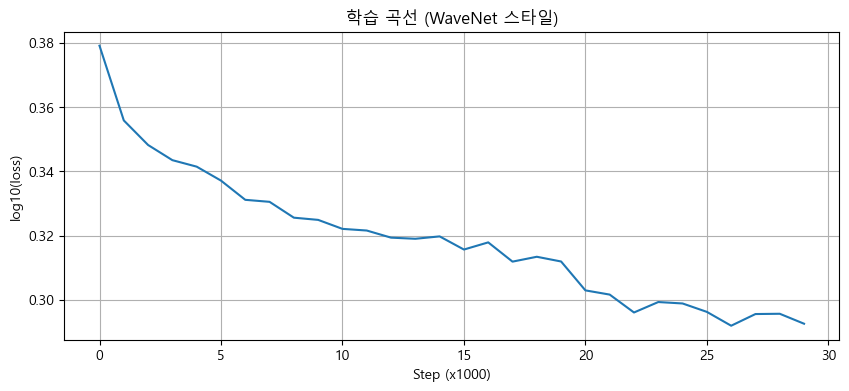

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.xlabel('Step (x1000)'); plt.ylabel('log10(loss)')
plt.title('학습 곡선 (WaveNet 스타일)')
plt.grid(True)
plt.show()

---
## 평가 & 생성

In [8]:
# 추론 모드
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

@torch.no_grad()
def eval_loss(X, Y):
    logits = model(X)
    return F.cross_entropy(logits, Y).item()

print(f'Train loss: {eval_loss(Xtr, Ytr):.4f}')
print(f'Val loss:   {eval_loss(Xdev, Ydev):.4f}')

Train loss: 1.9577
Val loss:   2.0281


In [9]:
# 이름 생성
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

lacelay.
jawin.
wurnoer.
elirya.
rose.
nalah.
keileank.
aamadi.
arkote.
ajue.
meilynn.
conial.
reie.
meira.
tanya.
eter.
annie.
elia.
zaysen.
luki.
